# Modeling and calibration of aggregate aviation demand for climate mitigation scenarios

This document has been published for reproducing the application presented in the World Conference on Transport Research - WCTR 2026 Toulouse 6-10 July 2026.

The goal of the paper is to review and compare different formulations for modeling long-term aviation demand based on prices and socioeconomic drivers.
The model calibration was performed outside of AeroMAPS, but the calibrated models were then implemented in AeroMAPS and used for simulating the evolution of aviation demand and its related impacts (emissions, climate, costs) under different scenarios.

Each scenario uses population, GDP, and carbon price based on an SSP2 mitigation scenario from the Scenario Database of the 6th IPCC's Assessment Report, with varying target radiative forcing levels by the end of the century. The forcing levels of 1.9 and 2.6 $W/m^2$ being in the range of respect of the Paris Agreement.


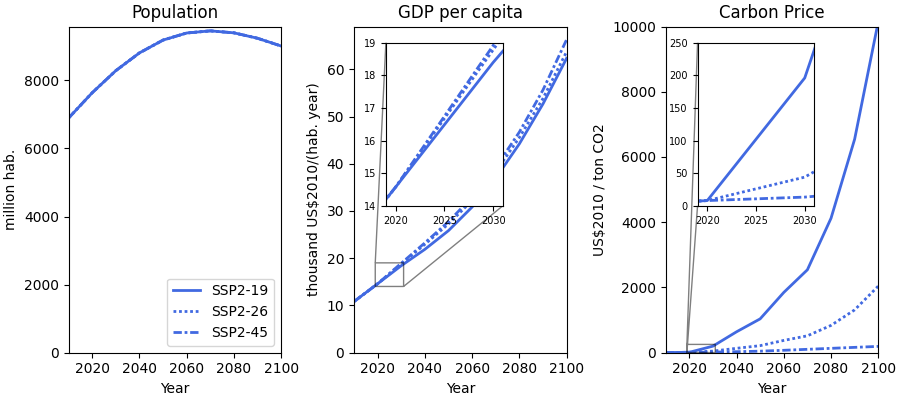

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aeromaps import create_process, assemble_processes
from get_data import get_ar6_input_data

ar6_data, ar6_years = get_ar6_input_data(start_year=2010, end_year=2100, plot_data=True)

## 2. Scenario comparison

To further explore the implications of different mitigation pathways, we employed the per-capita logistic model with fuel cost to compare multiple SSP2 scenarios with varying radiative forcing levels: SSP2-1.9, SSP2-2.6, and SSP2-4.5. Each scenario was evaluated under both FOSSIL and SAF fuel scenarios.

In [2]:
background_scenarios = ["SSP2-19", "SSP2-26", "SSP2-45"]
energy_scenarios = ["FOSSIL", "SAF"]

processes = {}
for background in background_scenarios:
    for energy in energy_scenarios:
        process = create_process(f"./configs/config_logistic_{energy.lower()}.yaml")

        process.parameters.population_reference_years = ar6_years
        process.parameters.population_reference_years_values = ar6_data["population"][background]

        process.parameters.gdp_per_capita_reference_years = ar6_years
        process.parameters.gdp_per_capita_reference_years_values = ar6_data["gdp_per_capita"][background]

        process.parameters.carbon_tax_reference_years = ar6_years
        process.parameters.carbon_tax_reference_years_values = ar6_data["carbon_tax"][background]

        process.parameters.exogenous_carbon_price_reference_years = ar6_years
        process.parameters.exogenous_carbon_price_reference_years_values = ar6_data["carbon_tax"][background]

        processes[energy + " (" + background + ")"] = process

assembly = assemble_processes(processes)
assembly.compute_all()

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as bottom-up, using top-down values for CAC computation.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\common\energy_carriers_factory.py:136: UserWarning: 
⚠️ Using Top-Down environmental model for abatement cost. Not recommended.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\impacts\generic_energy_model\bottom_up\abatement_cost.py:194: UserWarning: 
⚠️ Reference pathway for CAC (fossil_kerosene) is not defined as

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: exogenous_carbon_price_trajectory - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its entirety.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: socioeconomic_drivers Warning]
The first reference year (2010) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: socioeconomic_drivers - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its ent

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: exogenous_carbon_price_trajectory - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its entirety.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: socioeconomic_drivers Warning]
The first reference year (2010) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: socioeconomic_drivers - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its ent

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: exogenous_carbon_price_trajectory - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its entirety.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:220: UserWarning: 
[Interpolation Model: socioeconomic_drivers Warning]
The first reference year (2010) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:236: UserWarning: Warning Message - Model name: socioeconomic_drivers - Warning on aeromaps_interpolation_function: The last reference year for the interpolation is higher than end_year, the interpolation function is therefore not used in its ent

Text(0.5, 1.0, '')

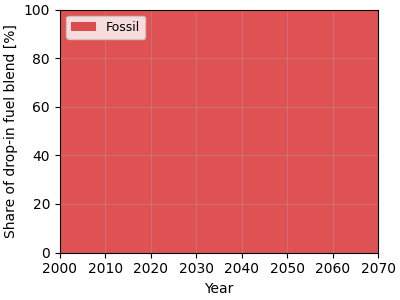

In [3]:
plot = processes["FOSSIL (SSP2-45)"].plot("blending_mandate")
plot.fig.set_size_inches(4, 3)
plot.ax.set_title("")
# plot.fig.savefig("fossil_mix.pdf")

interactive(children=(ToggleButtons(description='Visualisation mode:', options=(('All pathways - 1 year', 'per…

Text(0.5, 1.0, '')

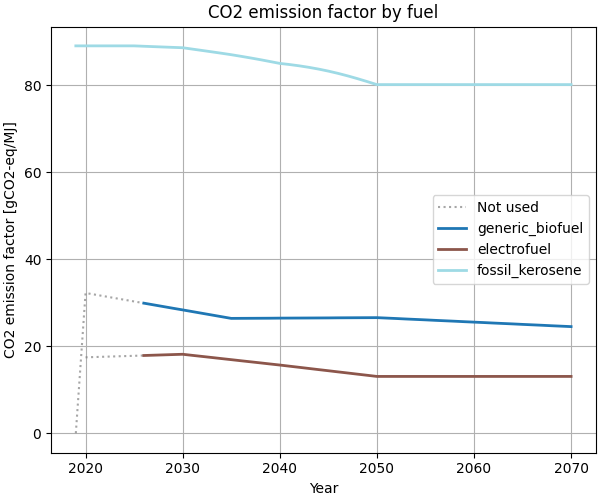

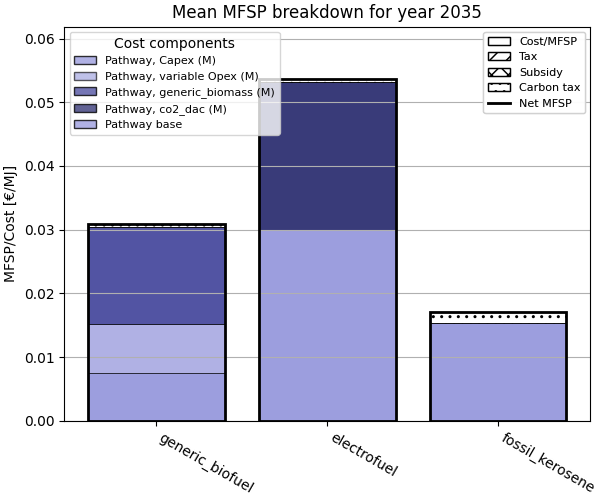

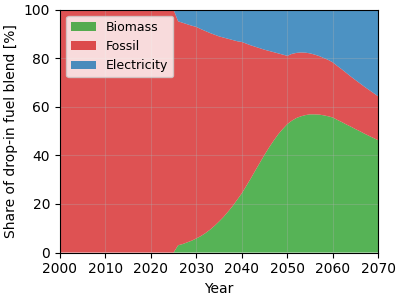

In [4]:
plot_a = processes["SAF (SSP2-45)"].plot("emission_factor_per_fuel")
plot_b = processes["SAF (SSP2-45)"].plot("mfsp_detailled")
plot_c = processes["SAF (SSP2-45)"].plot("blending_mandate")

plot_a.fig.set_size_inches(6, 5)
# plot_a.fig.savefig("emission_factor_fuel.pdf")

plot_b.fig.set_size_inches(6, 5)
# plot_b.fig.savefig("mfsp_fuel.pdf")

plot_c.fig.set_size_inches(4, 3)
plot_c.ax.set_title("")
# plot_c.fig.savefig("saf_mix.pdf")

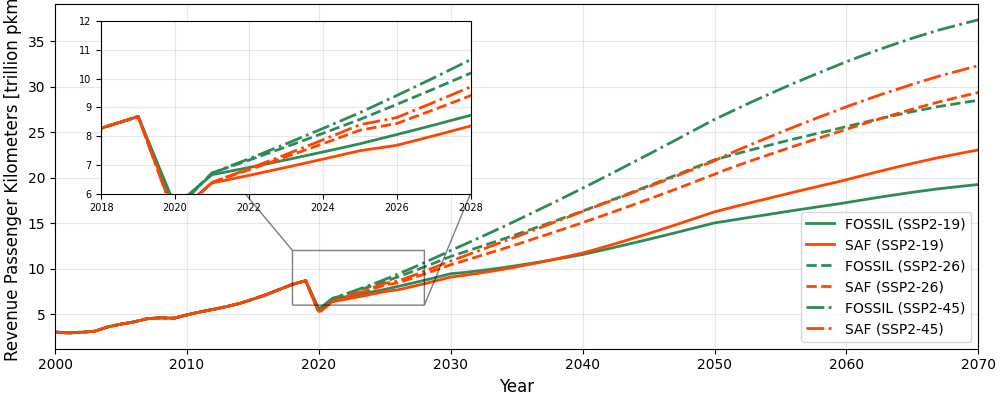

In [5]:
scenario_groups = {
    e: [name for name in processes.keys() if e in name] for e in energy_scenarios
}
colors = {"SAF": "orangered", "FOSSIL": "seagreen"}
plot_rpk = assembly.plot("rpk_comparison", scenario_groups=scenario_groups, legend="lower right", colors=colors)

ax_inset = plot_rpk.ax.inset_axes([0.05, 0.45, 0.4, 0.5])
assembly.plot(
    "rpk_comparison",
    scenario_groups=scenario_groups,
    fig=plot_rpk.fig,
    ax=ax_inset,
    legend=False,
    colors=colors,
)

ax_inset.set_xlim(2018, 2028)
ax_inset.set_ylim(6, 12)
ax_inset.set_ylabel("")
ax_inset.set_xlabel("")
ax_inset.set_title("")
ax_inset.tick_params(labelsize=7)
plot_rpk.ax.indicate_inset_zoom(ax_inset, edgecolor="black")
plot_rpk.ax.set_title("")
plot_rpk.fig.set_size_inches(10, 4)
plot_rpk.ax.set_xlim(2000, 2070)
plot_rpk.fig.savefig("scenario_comparison_rpk.pdf")

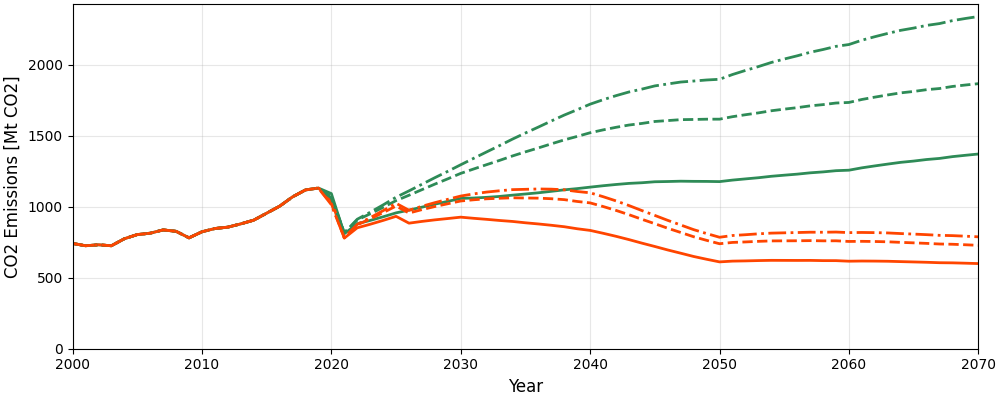

In [6]:
plot_co2 = assembly.plot("co2_emissions_comparison", scenario_groups=scenario_groups, colors=colors, legend=False)
plot_co2.ax.set_ylim(bottom=0)
plot_co2.ax.set_title("")
plot_co2.fig.set_size_inches(10, 4)
plot_co2.ax.set_xlim(2000, 2070)
plot_co2.fig.savefig("scenario_comparison_co2.pdf")

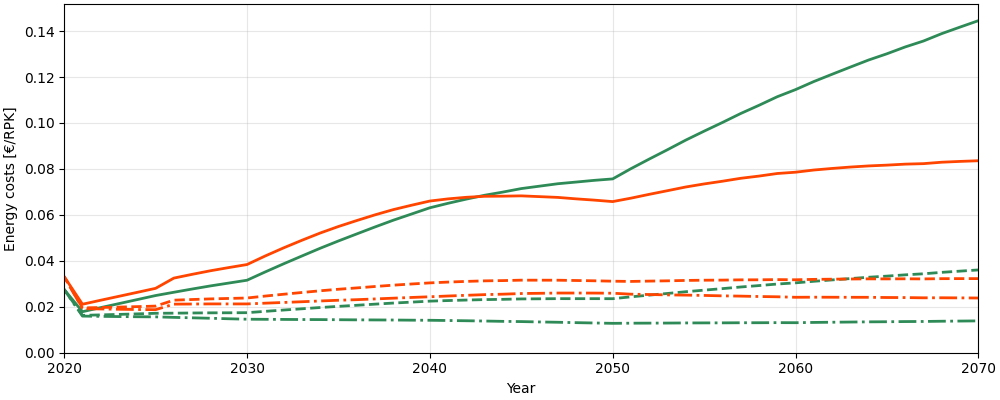

In [7]:
plot_cost = assembly.plot("all_energy_costs_per_rpk_comparison", scenario_groups=scenario_groups, colors=colors, legend=False)
plot_cost.ax.set_ylim(bottom=0)
plot_cost.ax.set_title("")
plot_cost.fig.set_size_inches(10, 4)
plot_cost.ax.set_xlim(2020, 2070)
plot_cost.fig.savefig("scenario_comparison_cost.pdf")

### 2.1 Scenario analysis

In [8]:
def plot_breakdown_for_one_case(energy_name, background_name):
    for p_name, p_obj in processes.items():
        if energy_name in p_name and background_name in p_name:
            p_plot = p_obj.plot("doc_net_energy_per_rpk_breakdown")
            p_plot.ax.set_ylim(bottom=0)
            p_plot.ax.set_title("")
            p_plot.ax.set_xlim(2020, 2070)
            p_plot.ax.set_ylim(0, 0.1)
            p_plot.fig.savefig(f"{energy_name}_{background_name}_cost.pdf")

#### 2.1.1 SSP2-4.5

This scenario has a feable carbon-tax.

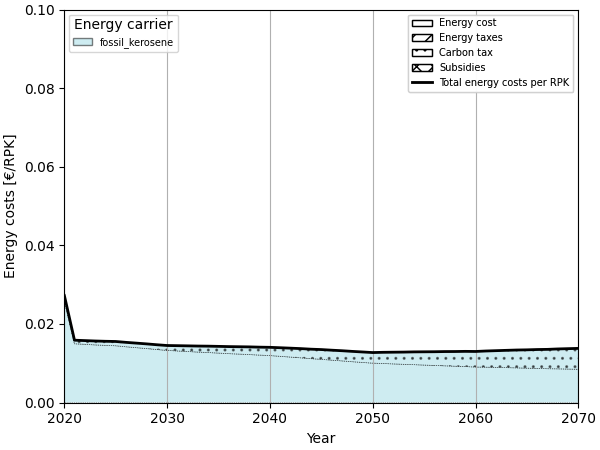

In [9]:
plot_breakdown_for_one_case("FOSSIL", "SSP2-45")

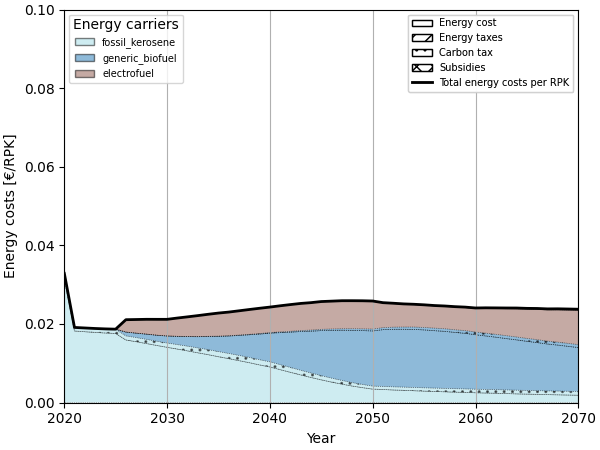

In [10]:
plot_breakdown_for_one_case("SAF", "SSP2-45")

#### 2.1.2 SSP2-2.6

This scenario has a moderate carbon-tax, compatible with the higher end of the Paris Agreement targets (+2°C).

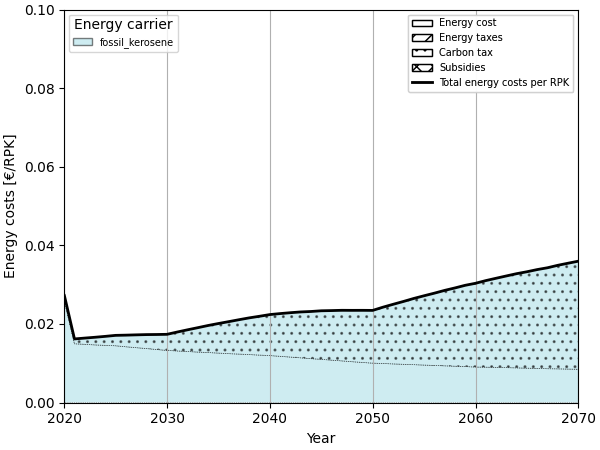

In [11]:
plot_breakdown_for_one_case("FOSSIL", "SSP2-26")

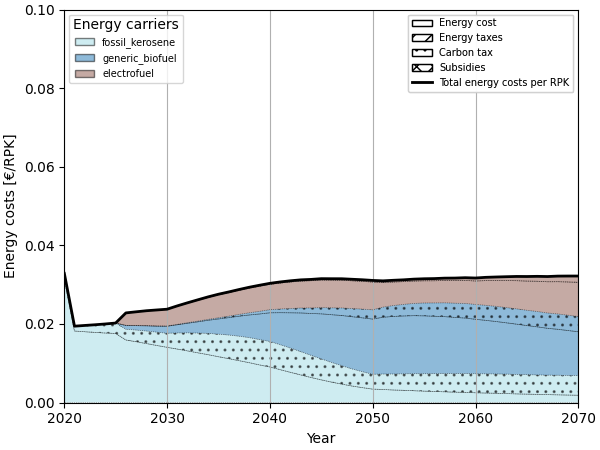

In [12]:
plot_breakdown_for_one_case("SAF", "SSP2-26")

#### 2.1.3 SSP2-1.9

This scenario has a strong carbon-tax, compatible with the lower end of the Paris Agreement targets (well below +2°C).

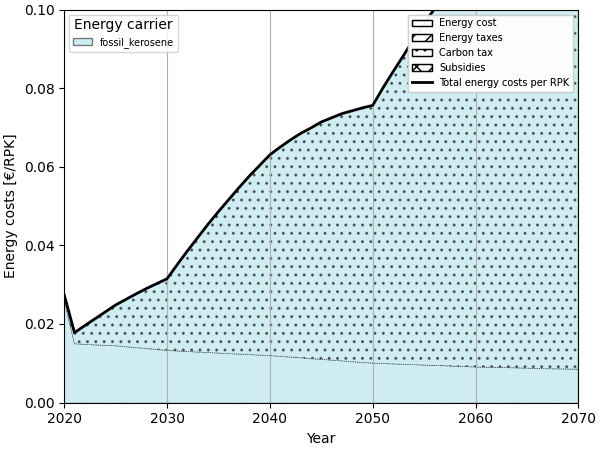

In [13]:
plot_breakdown_for_one_case("FOSSIL", "SSP2-19")

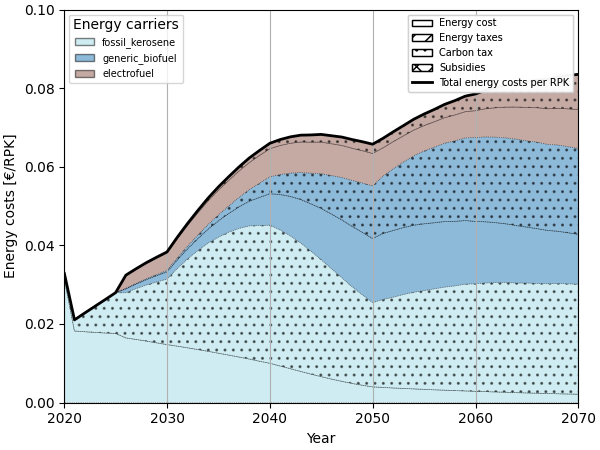

In [14]:
plot_breakdown_for_one_case("SAF", "SSP2-19")

### 2.2 Comparison with AR6 data

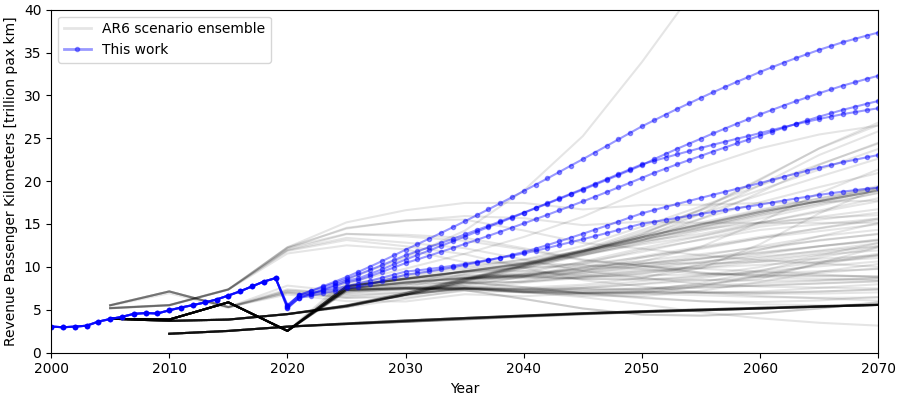

In [15]:
from get_data import get_ar6_rpk_data
from matplotlib.lines import Line2D

ar6_rpk, ar6_rpk_years = get_ar6_rpk_data(start_year=2000, end_year=2100, plot_data=False)

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")

for scenario_name, model_data in ar6_rpk.items():
    years = ar6_rpk_years.get(scenario_name, [])
    if not years:
        continue
    for values in model_data.values():
        if len(values) != len(years):
            continue
        ax.plot(years, np.array(values) * 1e-3, color="black", linestyle="-", alpha=0.1)

for process_name, process in processes.items():
    scenario_years = process.data["years"]["full_years"]
    scenario_rpk = process.data["vector_outputs"].loc[scenario_years, "rpk"] * 1e-12
    ax.plot(scenario_years, scenario_rpk, ".-", color="blue", alpha=0.4)

custom_lines = [
    Line2D([0], [0], color="k", alpha=0.1, lw=2),
    Line2D([0], [0], marker=".", color="blue", alpha=0.4, lw=2),
]

ax.legend(custom_lines, ["AR6 scenario ensemble", "This work"], loc="upper left")
ax.set_xlim(2000, 2070)
ax.set_ylim(0, 40)
ax.set_xlabel("Year")
ax.set_ylabel("Revenue Passenger Kilometers [trillion pax km]")
fig.savefig("scenario_comparison_rpk_vs_ar6.pdf")

The issue here is that some models don't have the same scope (commercial, international, domestic) so difficult to compare

In [16]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())